<a href="https://colab.research.google.com/github/RichardMorris/TRUR2290-25-26/blob/main/linear_regression_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression Example

### Download Data set

In [ ]:
!curl -L -o ./salary-dataset-simple-linear-regression.zip https://www.kaggle.com/api/v1/datasets/download/abhishek14398/salary-dataset-simple-linear-regression
!unzip ./salary-dataset-simple-linear-regression.zip -d .

### Import Packages

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import numpy as np
import csv
import pandas

### Load Data

In [ ]:
with open("./Salary_dataset.csv", mode="r") as csvFile:
  reader = csv.reader(csvFile)
  data = []
  skipHeader = True
  for row in reader:
    if skipHeader:
      skipHeader = False
      continue
    data.append((float(row[1]),float(row[2])))

plt.scatter([d[0] for d in data],[d[1] for d in data])

### Bad Trend Line

Define a function with a bad trendline 

In [5]:
def BadLine(x):
  m = -3000
  c = 100000
  return m * x + c

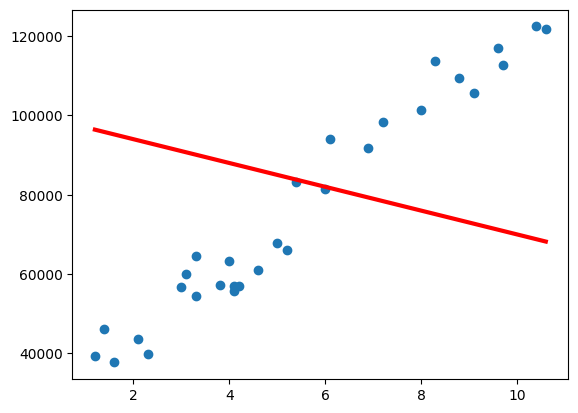

In [6]:
plt.plot([d[0] for d in data],[BadLine(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])

The error between the *actual* data and the trend line can be calculated by first finding the difference between the predicted and the actual.

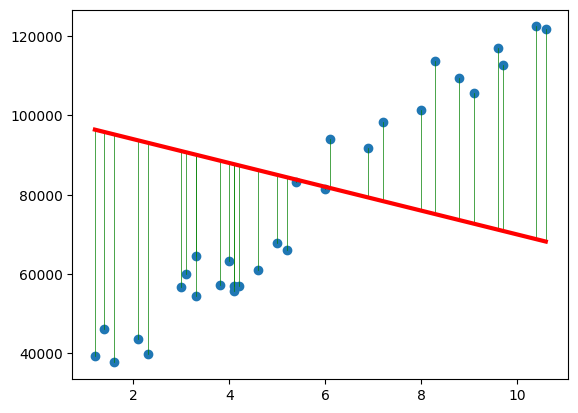

In [7]:
Errors = []
for datum in data:
  Errors.append(
      ((datum[0],datum[0]),
      (BadLine(datum[0]),datum[1]))
  )
for error in Errors:
  plt.plot(error[0],error[1],c='green',linewidth='0.5')


plt.plot([d[0] for d in data],[BadLine(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])


In [8]:
def MeanSquareError(data, line):
  TotalSquareError = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    TotalSquareError += (y - line(x))**2
  return TotalSquareError / len(data)

In [9]:
MeanSquareError(data,BadLine)

1298137757.7333333

Define a function for a better trend line

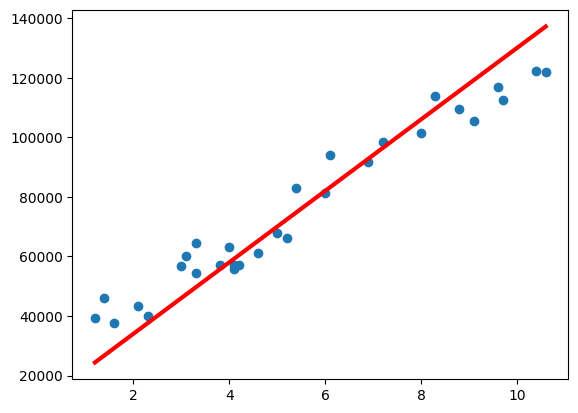

In [10]:
def BetterLine(x):
  m = 12000
  c = 10000
  return m * x + c

plt.plot([d[0] for d in data],[BetterLine(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])

In [11]:
MeanSquareError(data,BetterLine)

82985357.73333332

## Finding better lines

First define a function with two parameters m,c for a general line, and a new function for MSE

In [ ]:
def GenLine(x, m, c):
  return m * x + c

def MeanSquareError(data, m, c, line):
  TotalSquareError = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    TotalSquareError += (y - line(x, m, c))**2
  return TotalSquareError / len(data)


### Generate a heat map giving MSE for a set of lines

In [ ]:

results = np.zeros((30,30))
mIntervals = np.arange(13000,7000,-200)
cIntervals = np.arange(9000,39000,1000)

for i,m in enumerate(mIntervals):
  for j,c in enumerate(cIntervals):
    results[i,j] = MeanSquareError(data, m, c, GenLine)
ax = sns.heatmap(results, xticklabels=cIntervals, yticklabels=mIntervals,norm=LogNorm(),cmap="RdYlGn_r",cbar_kws={'label': 'Mean Squared Error'})
ax.set(xlabel="c - Intersect", ylabel="m - Gradient")
ax

### Finding a better line

Now a function to update the M-parameter. Given m and c, for each point find the y-error between the actual and predicted value.
The total total = sum(x * error) and the change in m is total/len.

In [ ]:
def UpdateM(data, m, c):
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    y_error = y - (m*x + c)
    Total += x * y_error
  return -2 * Total / len(data)


To update C, this is just the average of the y-errors. 

In [ ]:

def UpdateC(data, m, c):
  Total = 0.0
  for point in data:
    x = point[0]
    y = point[1]
    Total += (y - (m*x + c))
  return -2 * Total / len(data)

Now iterate. Start with the bad example, loop a thousand times, at each step update the m and c values.

In [ ]:
# learningRate = 0.025
learningRate = 0.01
m = 10000
c = 10000

loss = [MeanSquareError(data,m,c,GenLine)]
mc = [{"m":m,"c":c}]

for iter in range(1000):
  _m = learningRate * UpdateM(data, m, c)
  c -= learningRate * UpdateC(data, m, c)
  m -= _m
  loss.append(MeanSquareError(data,m,c,GenLine))
  mc.append({"m":m,"c":c})

print(f"m: {m}, c: {c}")
MeanSquareError(data, m, c, GenLine)

Define the best line using the final result of iteration

In [ ]:
def BestLine(x):
  return m * x + c

plt.plot([d[0] for d in data],[BestLine(float(d[0])) for d in data],c="red",linewidth='3')
plt.scatter([d[0] for d in data],[d[1] for d in data])

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

line, = ax.plot(loss, lw=2)

ax.set_yscale('log')